In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('/content/train.csv')
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [67]:
df.describe()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
count,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,...,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000
mean,4.115224,87.557631,72.988310,71.290627,58.539916,1.165608,1.063884,115.601251,33.225218,44.391893,...,3.153127,3.056536,3.055885,1.295682,1.052841,2.041010,1.483007,0.839342,0.673987,34.421219
std,1.439295,29.676497,33.490406,31.030272,36.651067,0.364930,0.401423,54.626887,26.967752,20.035430,...,1.191249,1.046257,1.174815,0.393155,0.380291,1.242345,0.978176,0.484676,0.455580,34.254362
min,1.000000,6.941000,6.423452,5.320573,1.960849,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000210
25%,3.000000,72.458076,52.143839,58.041225,35.248990,0.966676,0.775363,78.512902,16.824174,32.890369,...,2.116732,2.279705,2.091251,1.060857,0.775678,1.000000,0.921454,0.451754,0.306892,5.365000
50%,4.000000,84.922750,60.696571,66.361592,39.918385,1.199541,1.146783,122.906070,26.636008,45.123500,...,2.618182,2.615321,2.434057,1.368922,1.166532,2.000000,1.063077,0.800000,0.500000,20.000000
75%,5.000000,100.404410,86.103540,78.116681,73.113234,1.444537,1.359418,154.119320,38.356908,59.322812,...,4.026201,3.727919,3.914868,1.589027,1.330801,3.000000,1.918400,1.200000,1.020436,63.000000
max,9.000000,208.980400,208.980400,208.980400,208.980400,1.983797,1.958203,207.972460,205.589910,101.019700,...,7.000000,7.000000,7.000000,2.141963,1.949739,6.000000,6.992200,3.000000,3.000000,185.000000


In [68]:
X = df.drop('critical_temp', axis = 1)
y = df['critical_temp']

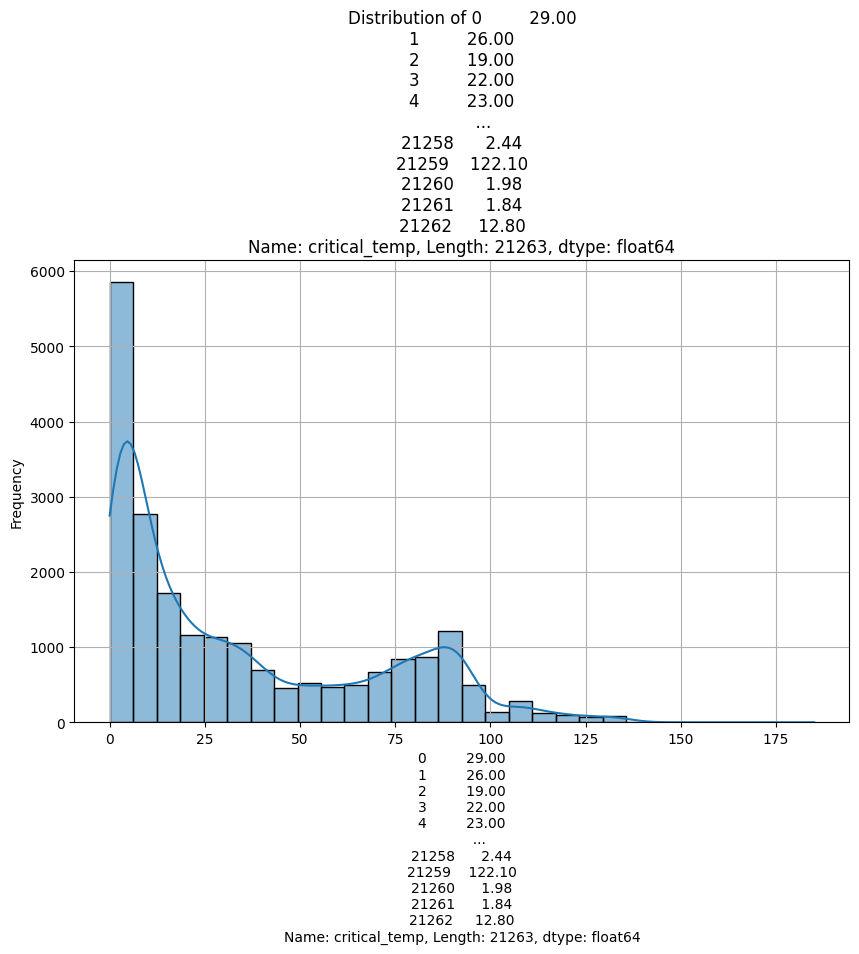

In [69]:
column_name = y
plt.figure(figsize=(10, 6))
sns.histplot(column_name, kde=True, bins=30)
plt.title(f'Distribution of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [70]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [71]:
columns = X_train.columns

In [72]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)

X_test_imputed = imputer.transform(X_test)

In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

X_test_scaled = scaler.transform(X_test_imputed)

In [74]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train_scaled)

PCA()

In [75]:
feature_names = X_train.columns
explained_variance_ratio = pca.explained_variance_ratio_
top_n = 25
explained_variance_ratio_top = explained_variance_ratio[:top_n]

top_features = []
for i in range(top_n):
    component_loadings = pca.components_[i]
    top_feature_idx = np.argmax(np.abs(component_loadings))
    top_features.append(feature_names[top_feature_idx])

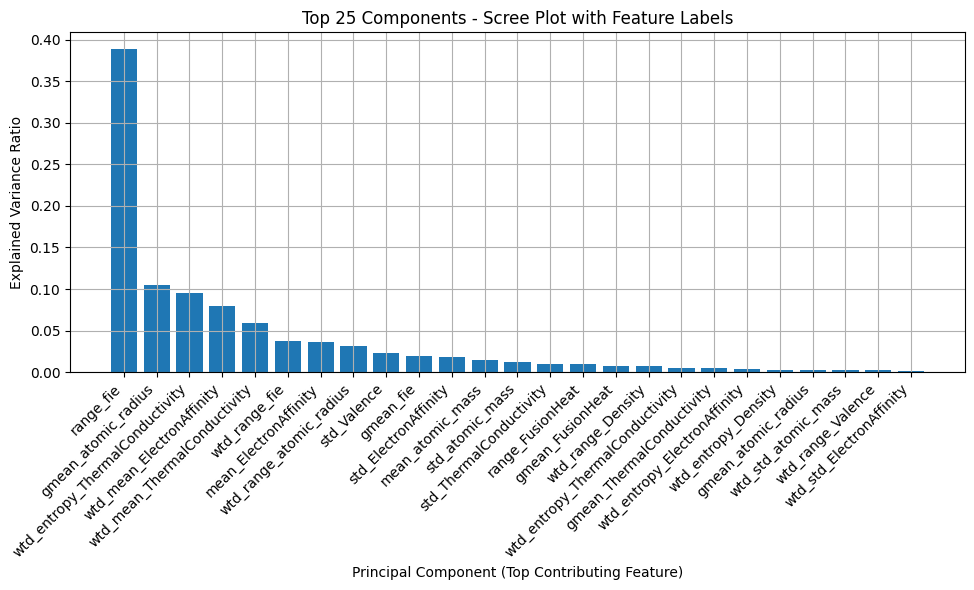

In [76]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, top_n + 1), explained_variance_ratio_top, tick_label=top_features)
plt.xlabel('Principal Component (Top Contributing Feature)')
plt.ylabel('Explained Variance Ratio')
plt.title('Top 25 Components - Scree Plot with Feature Labels')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

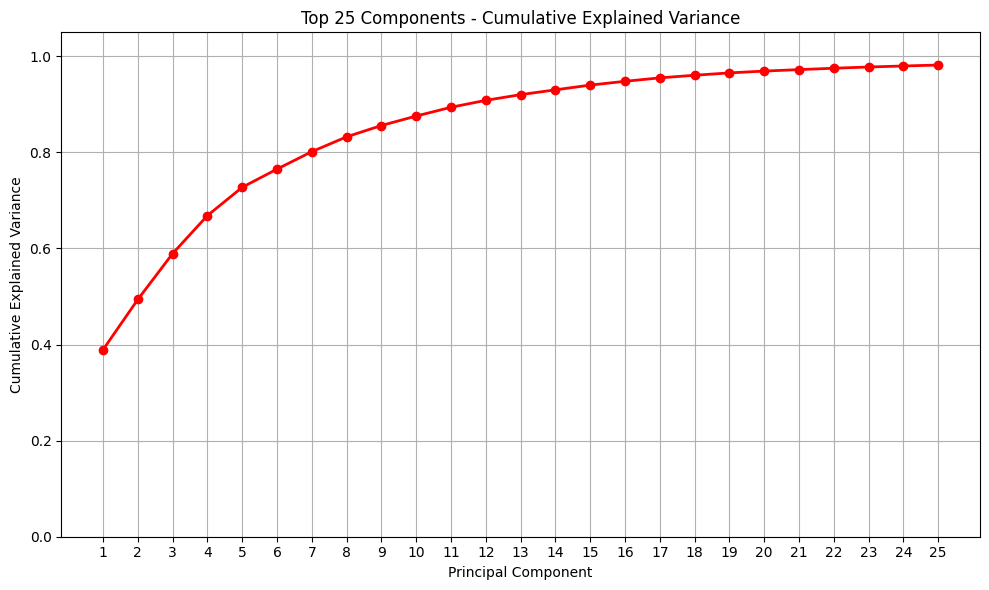

In [77]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, top_n + 1), np.cumsum(explained_variance_ratio_top), 'ro-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Top 25 Components - Cumulative Explained Variance')
plt.xticks(range(1, top_n + 1))
plt.ylim([0, 1.05])
plt.grid(True)
plt.tight_layout()
plt.show()

In [78]:
X_train = X_train[top_features]
X_test = X_test[top_features]

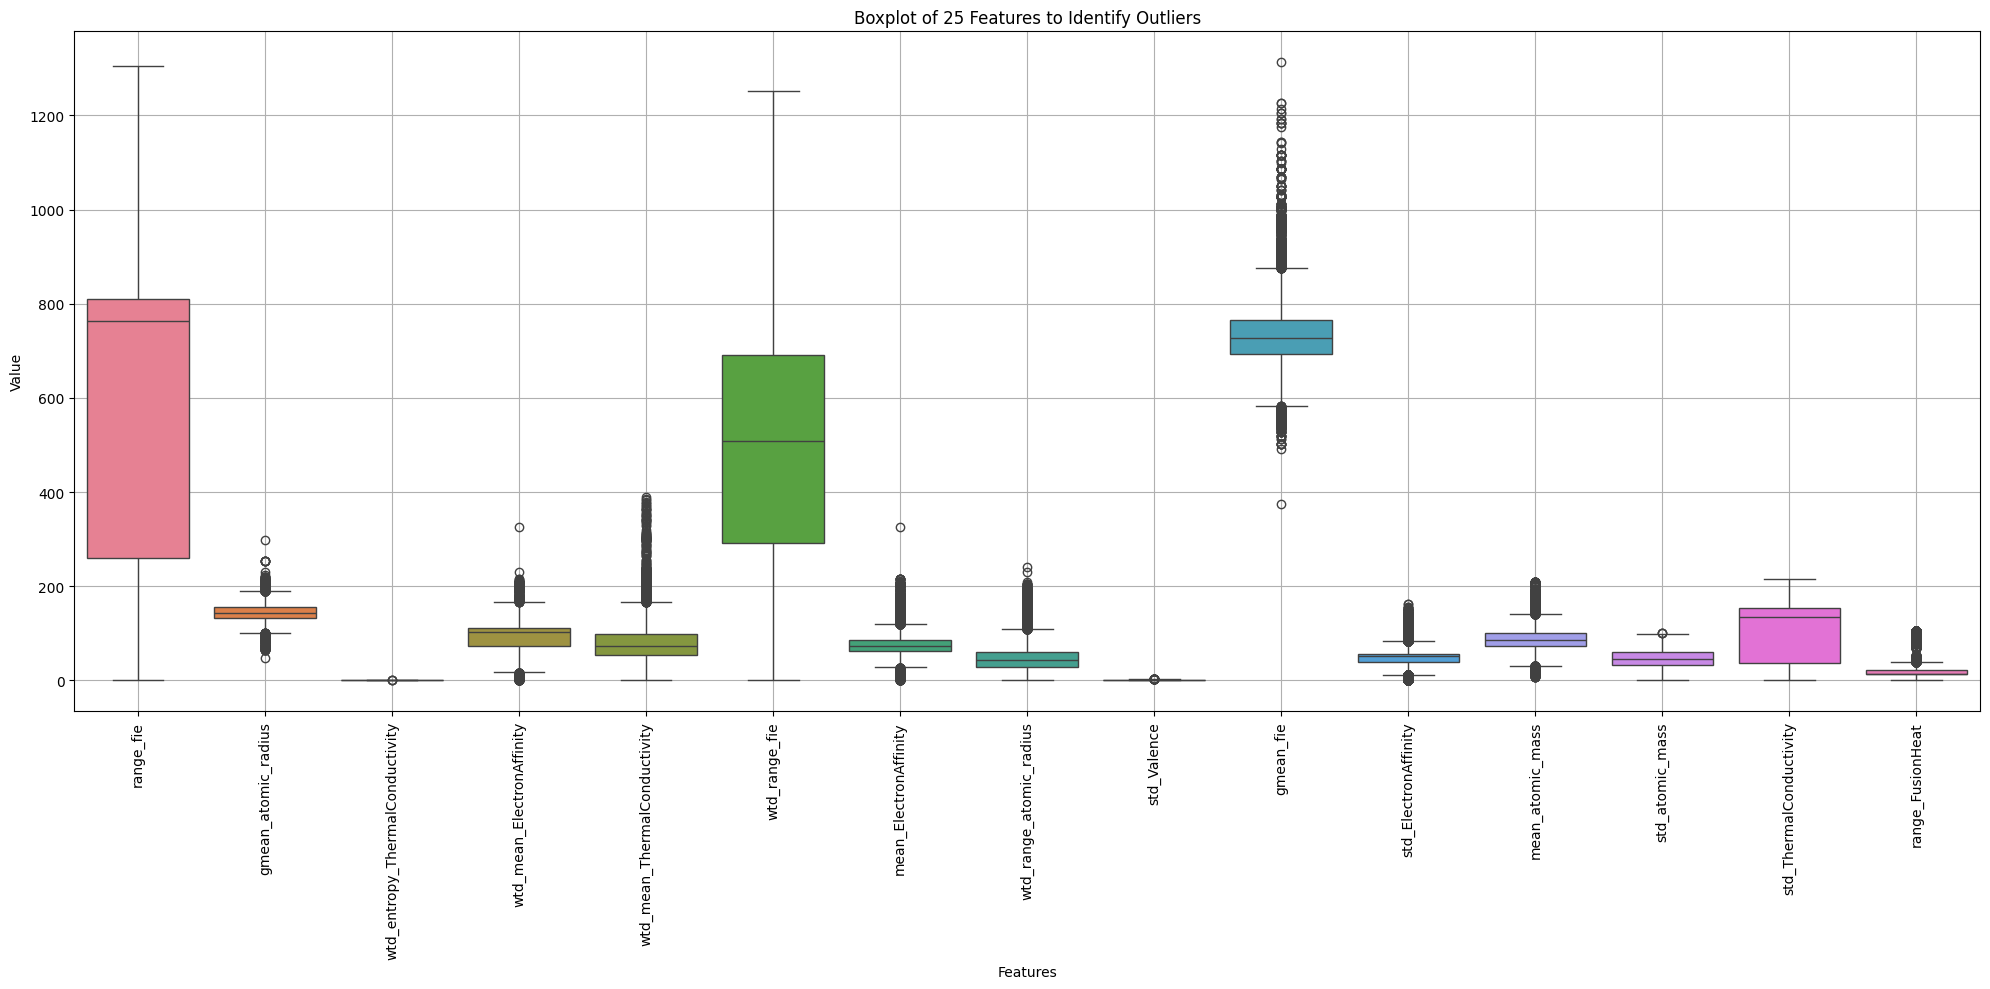

In [79]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=X_train.iloc[:, :15], orient='v')
plt.title("Boxplot of 25 Features to Identify Outliers")
plt.xlabel("Features")
plt.ylabel("Value")
plt.grid(True)
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

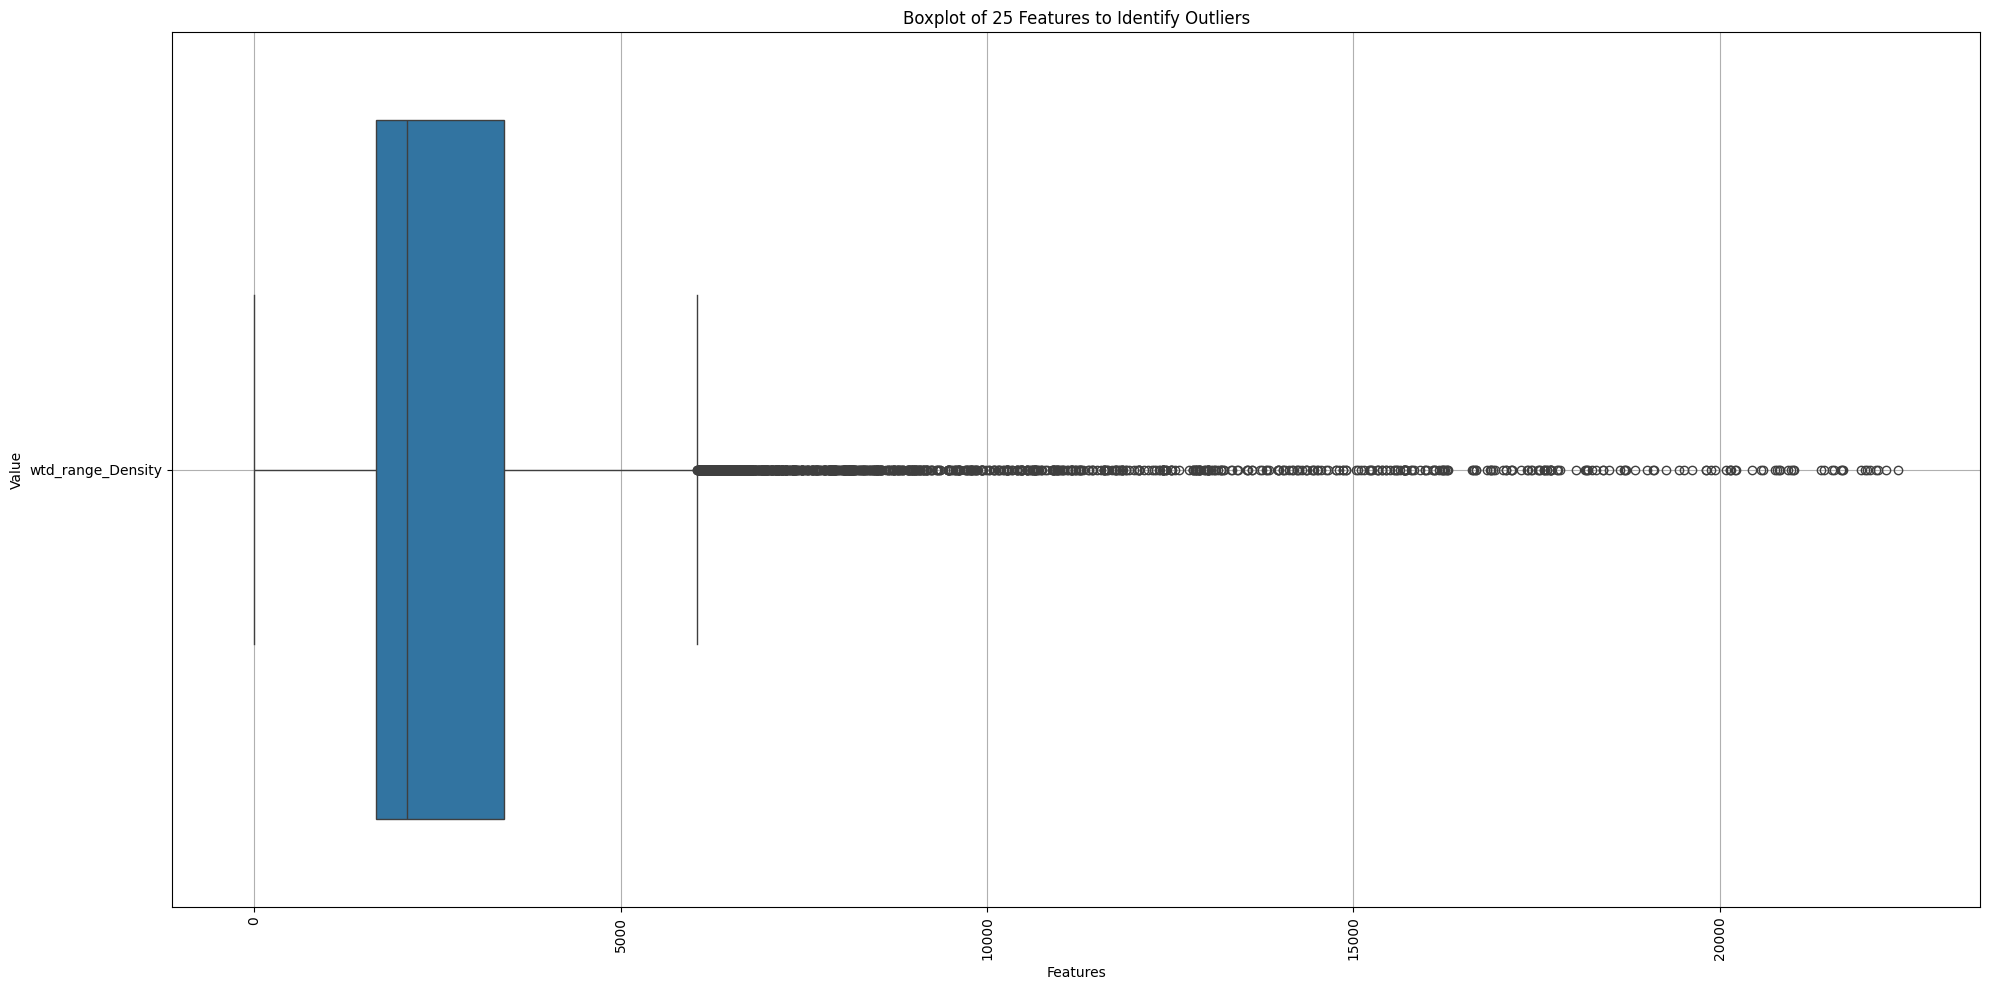

In [80]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=X_train.iloc[:, 16:17], orient='h')
plt.title("Boxplot of 25 Features to Identify Outliers")
plt.xlabel("Features")
plt.ylabel("Value")
plt.grid(True)
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

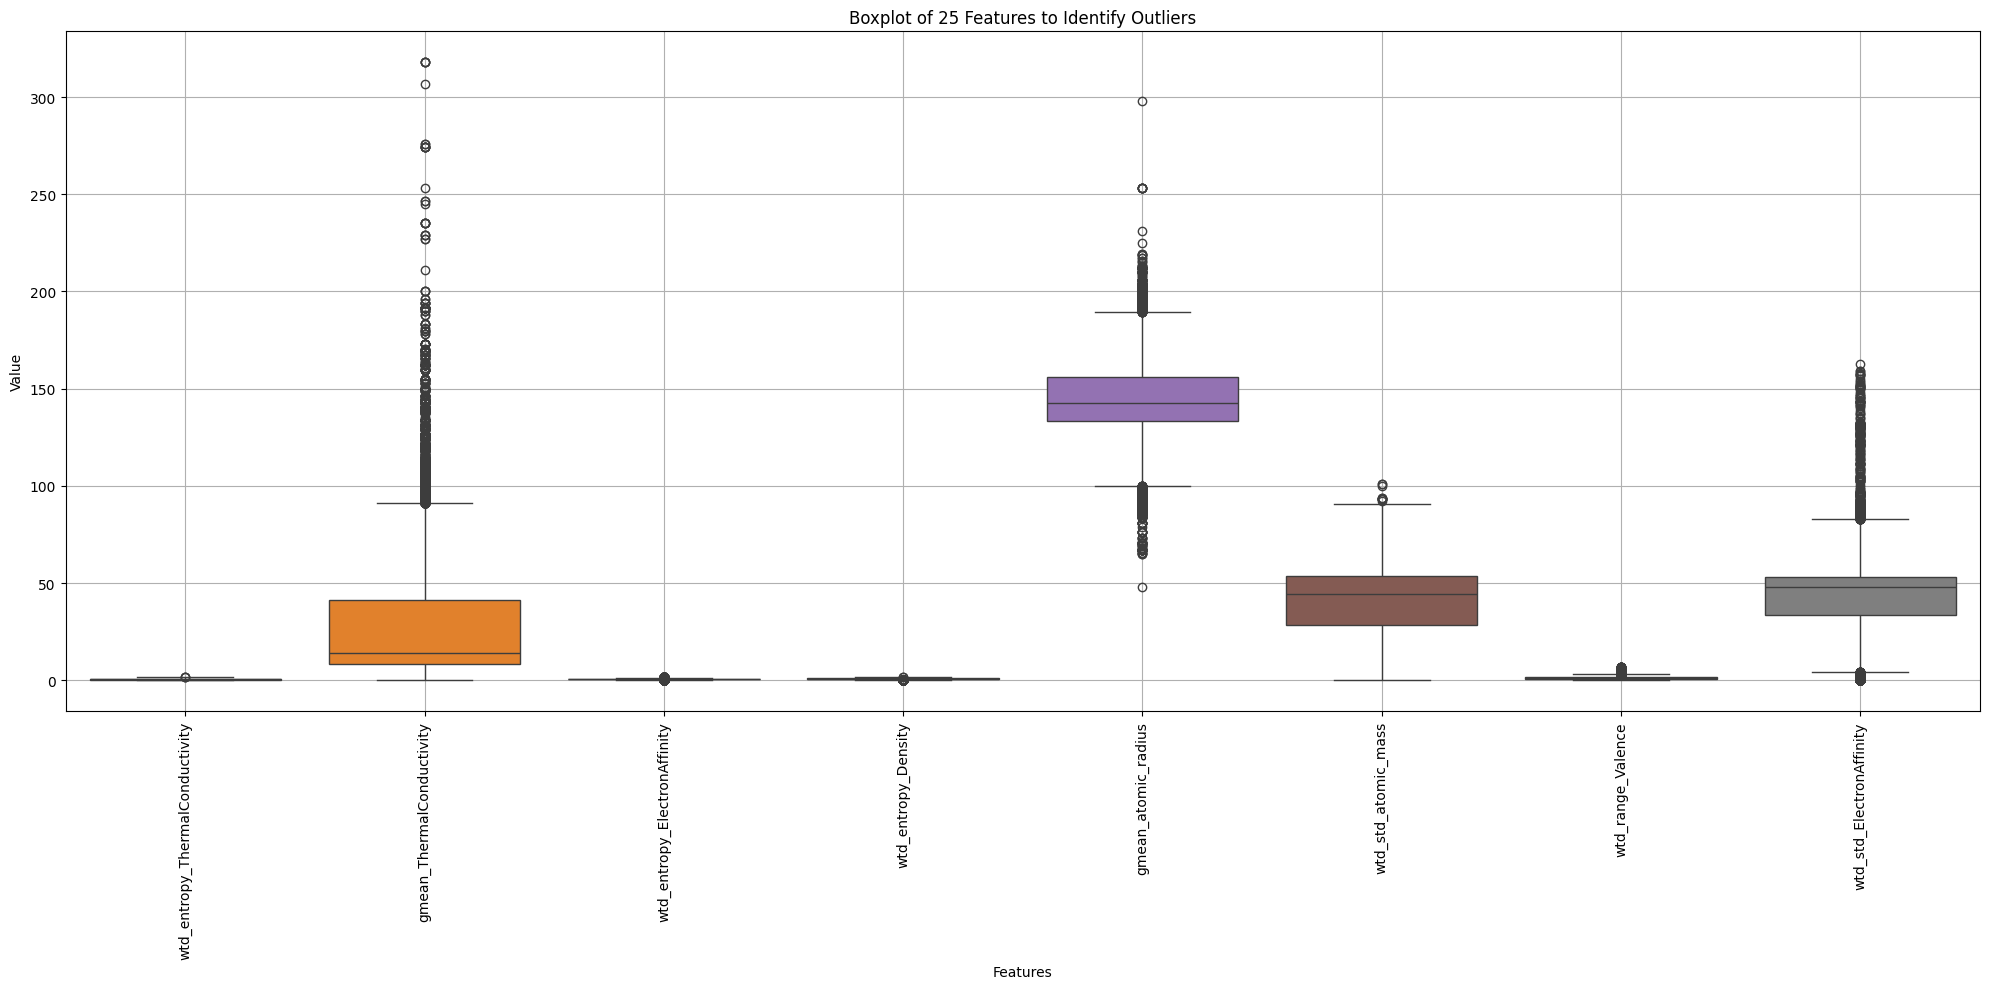

In [81]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=X_train.iloc[:, 17:26], orient='v')
plt.title("Boxplot of 25 Features to Identify Outliers")
plt.xlabel("Features")
plt.ylabel("Value")
plt.grid(True)
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

In [82]:
from sklearn.metrics import make_scorer, mean_squared_error

def neg_root_mean_squared_error(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(neg_root_mean_squared_error, greater_is_better=False)

**Non-Linear Approaches**

In [83]:
models = {
    'SVR_RBF': SVR(kernel='rbf', C=10, gamma='scale'),

    'Polynomial_Regression': make_pipeline(
        PolynomialFeatures(degree=3, include_bias=False),
        LinearRegression()
    ),

    'Spline_Regression': make_pipeline(
        SplineTransformer(degree=3, n_knots=5, include_bias=False),
        LinearRegression()
    )
}

results = {}
for name, model in models.items():
    rmse_scores = cross_val_score(model, X_train, y_train, cv=5, scoring=rmse_scorer)
    results[name] = {
        'Mean_RMSE': np.mean(rmse_scores),
        'Std_RMSE': np.std(rmse_scores)
    }

results_df = pd.DataFrame(results).T.sort_values(by='Mean_RMSE')
print("Model Comparison Non-Linear Approaches :\n", results_df)

best_model_name = results_df.index[0]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
print(f"\nFinal model trained on top 25 features using: {best_model_name}")

Model Comparison Non-Linear Approaches :
                        Mean_RMSE  Std_RMSE
Spline_Regression      17.911881  0.232421
Polynomial_Regression  21.077551  2.590343
SVR_RBF                23.368023  0.498919

Final model trained on top 25 features using: Spline_Regression


In [84]:
y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print("\nFinal Evaluation on Test Set:")
print(f"1. RMSE: {rmse_test:.4f}")
print(f"2. MAE: {mae_test:.4f}")
print(f"3. R² Score: {r2_test:.4f}")


Final Evaluation on Test Set:
1. RMSE: 17.3093
2. MAE: 13.2720
3. R² Score: 0.7397


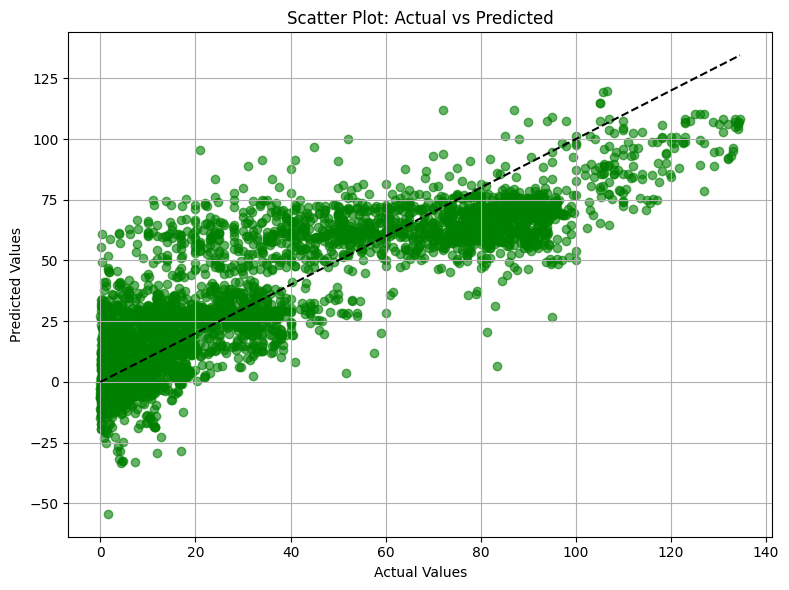

In [85]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Scatter Plot: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

**Tree-based Approaches**

In [86]:
models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    rmse_scores = cross_val_score(model, X_train, y_train, cv=5, scoring=rmse_scorer)
    results[name] = {
        'Mean_RMSE': np.mean(rmse_scores),
        'Std_RMSE': np.std(rmse_scores)
    }

results_df = pd.DataFrame(results).T.sort_values(by='Mean_RMSE')
print("Tree-Based Model Comparison :\n", results_df)

best_model_name = results_df.index[0]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
print(f"\nFinal model trained on top 25 features using: {best_model_name}")

Tree-Based Model Comparison :
                   Mean_RMSE  Std_RMSE
ExtraTrees         9.760100  0.419617
RandomForest       9.931116  0.304781
GradientBoosting  13.780652  0.250455

Final model trained on top 25 features using: ExtraTrees


In [87]:
y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print("\nFinal Evaluation on Test Set:")
print(f"1. RMSE: {rmse_test:.4f}")
print(f"2. MAE: {mae_test:.4f}")
print(f"3. R² Score: {r2_test:.4f}")


Final Evaluation on Test Set:
1. RMSE: 9.0317
2. MAE: 4.9640
3. R² Score: 0.9291


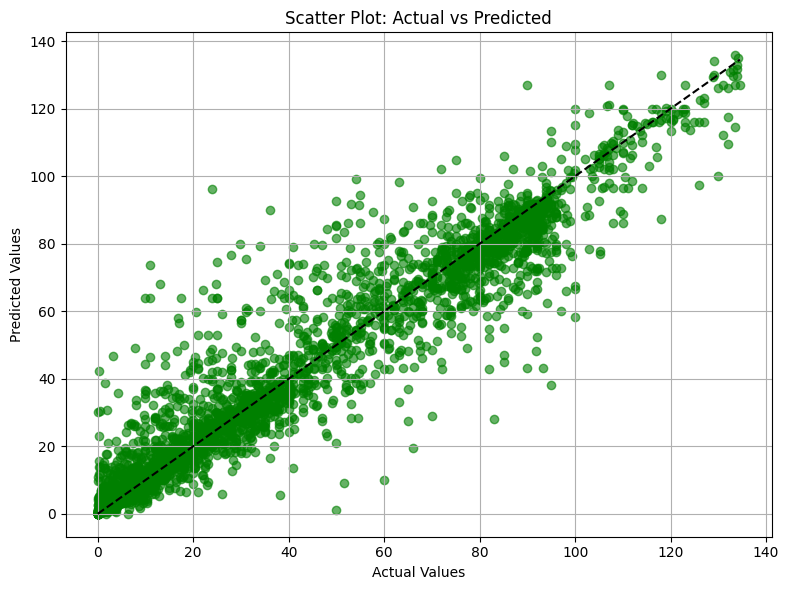

In [88]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Scatter Plot: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

**Linear Approaches**

In [89]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=10000)
}

results = {}
for name, model in models.items():
    rmse_scores = cross_val_score(model, X_train, y_train, cv=5, scoring=rmse_scorer)
    results[name] = {
        'Mean_RMSE': np.mean(rmse_scores),
        'Std_RMSE': np.std(rmse_scores)
    }

results_df = pd.DataFrame(results).T.sort_values(by='Mean_RMSE')
print("Linear Model Comparison :\n", results_df)

best_model_name = results_df.index[0]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

print(f"\nFinal linear model trained on top 25 features using: {best_model_name}")

Linear Model Comparison :
                   Mean_RMSE  Std_RMSE
LinearRegression  20.968722  0.406809
Ridge             20.968727  0.406436
Lasso             20.969332  0.404193

Final linear model trained on top 25 features using: LinearRegression


In [90]:
y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print("\nFinal Evaluation on Test Set:")
print(f"1. RMSE: {rmse_test:.4f}")
print(f"2. MAE: {mae_test:.4f}")
print(f"3. R² Score: {r2_test:.4f}")


Final Evaluation on Test Set:
1. RMSE: 20.6272
2. MAE: 16.4810
3. R² Score: 0.6304


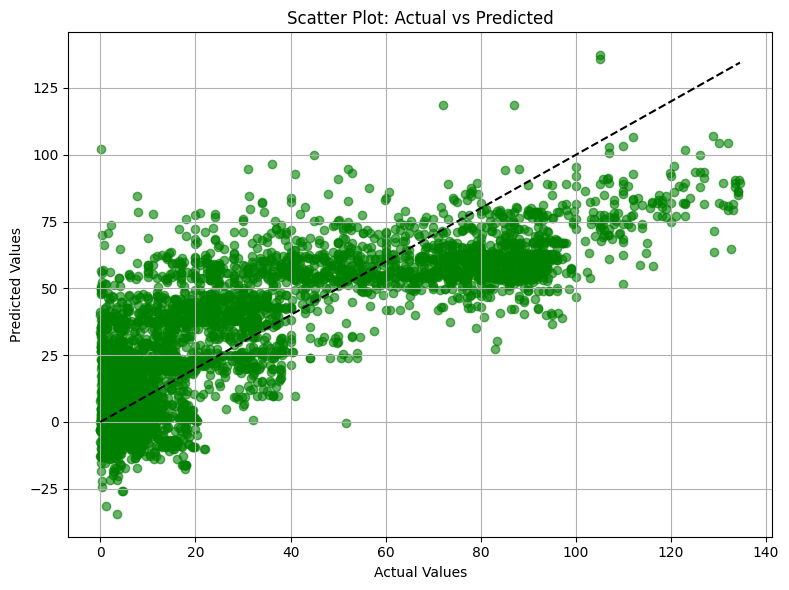

In [91]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Scatter Plot: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

**Neural Network**

In [92]:
X_train_nn = X_train[top_features]
X_test_nn = X_test[top_features]

scaler = StandardScaler()
X_train_scaled_nn = scaler.fit_transform(X_train_nn)
X_test_scaled_nn = scaler.transform(X_test_nn)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled_nn.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history = model.fit(X_train_scaled_nn, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=0)

In [93]:
y_pred_nn = model.predict(X_test_scaled_nn).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mae = mean_absolute_error(y_test, y_pred_nn)
r2 = r2_score(y_test, y_pred_nn)

print("\nNeural Network Performance on Test Set:")
print(f"1. RMSE: {rmse:.4f}")
print(f"2. MAE: {mae:.4f}")
print(f"3. R² Score: {r2:.4f}")

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Neural Network Performance on Test Set:
1. RMSE: 12.5509
2. MAE: 8.1346
3. R² Score: 0.8632


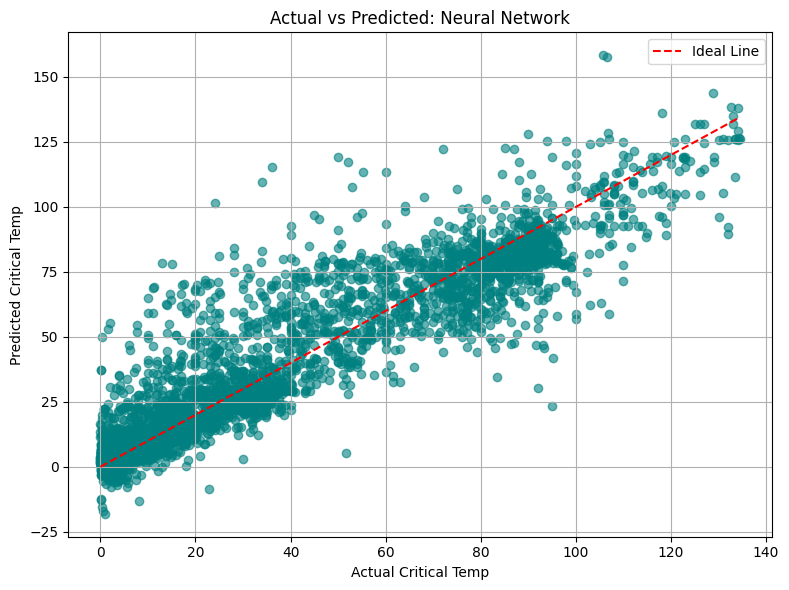

In [94]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Ideal Line")
plt.xlabel('Actual Critical Temp')
plt.ylabel('Predicted Critical Temp')
plt.title('Actual vs Predicted: Neural Network')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()